In [ ]:
import mysql.connector

# 1. MySQLの本棚（world）に接続する（ユーザー名はroot、パスワードは無し）
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="world"
)
cursor = conn.cursor()

# 2. PythonからSQLの呪文を送る
cursor.execute("SELECT name, population FROM country WHERE code = 'JPN'")
row = cursor.fetchone() # 1行だけ取ってくる（fetchone）。複数行ならfetchall(),fetchmany()もある

# 3. 取ってきたデータをPythonの画面にプリントする
print("=== 日本のデータ（Pythonが取得） ===")
print(f"国名: {row[0]}")
print(f"人口: {row[1]:,} 人")

# 4. 最後に接続を閉じる
cursor.close()
conn.close()

=== 日本のデータ（Pythonが取得） ===
国名: Japan
人口: 125,000,000 人


グラフの画像を保存しました！


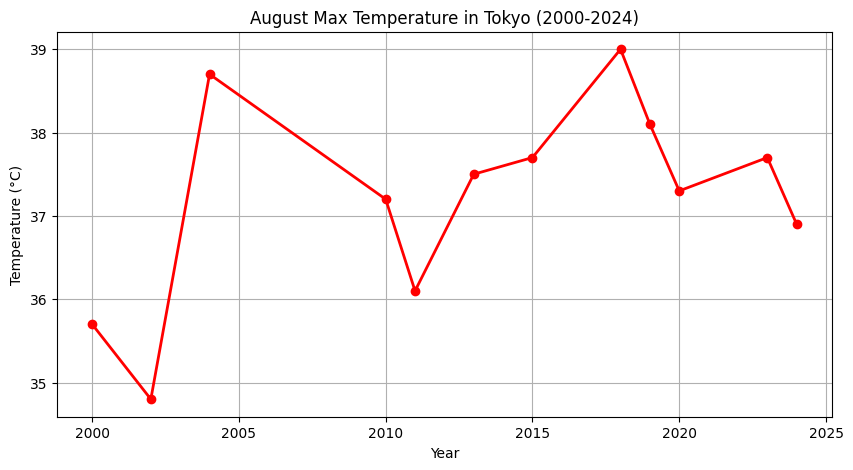

In [ ]:
import mysql.connector
import matplotlib.pyplot as plt

# MySQLに接続
conn = mysql.connector.connect(
    host="localhost", user="root", password="", database="world"
)
cursor = conn.cursor()

# 東京の天気データを「年が古い順」に全部取ってくる
cursor.execute("SELECT year, max_temp FROM weather ORDER BY year ASC")
rows = cursor.fetchall()  # ここで全部（fetchall）受け取る！

# 取ってきたデータを、グラフ用の「年リスト」と「気温リスト」に分ける
years = []
temps = []
for row in rows:
    years.append(row[0])  # 年をリストに追加
    temps.append(row[1])  # 気温をリストに追加

# ここからグラフの見た目を作る
plt.figure(figsize=(10, 5))  # グラフの横と縦のサイズを決める

# 折れ線グラフを描く（色は赤、点は丸、線の太さは2）
plt.plot(years, temps, color="red", marker="o", linewidth=2)

# グラフのタイトルや、横軸・縦軸のラベルをつける
plt.title("August Max Temperature in Tokyo (2000-2024)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)  # 背景にマス目（グリッド）を入れて見やすくする

# 5. グラフを「tokyo_weather.png」という名前の画像ファイルで保存！
plt.savefig("tokyo_weather.png")

# 6. 後片付け
cursor.close()
conn.close()

print("グラフの画像を保存しました！")

In [5]:
import urllib.request
import mysql.connector
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. ネット上のオープンデータ（CSV）にアクセスして読み込む
# --------------------------------------------------
url = "https://raw.githubusercontent.com/tatsuya-koyama/datasets/main/tokyo_august_temp.csv"
# ネット上のCSVを開いて、文字として読み込む
response = urllib.request.urlopen(url)
csv_data = response.read().decode('utf-8')

print("--- ネット上の生データ（CSV）の中身 ---")
print(csv_data)
print("---------------------------------------")

# --------------------------------------------------
# 2. 読み込んだデータを1行ずつループしてMySQLに保存する（INSERT）
# --------------------------------------------------
conn = mysql.connector.connect(
    host="localhost", user="root", password="", database="world"
)
cursor = conn.cursor()

# CSVのデータを改行ごとにバラバラにして、1行ずつ処理する
lines = csv_data.strip().split('\n')
for line in lines:
    # カンマで「年」と「気温」に切り分ける
    year, temp = line.split(',')
    
    # MySQLのweatherノートにガチャッと差し込む呪文
    sql = "INSERT INTO weather (year, max_temp) VALUES (%s, %s) ON DUPLICATE KEY UPDATE max_temp = %s"
    cursor.execute(sql, (int(year), float(temp), float(temp)))

conn.commit() # 反映を確定させるおまじない
print("MySQLへのデータ保存が完了しました！")

# --------------------------------------------------
# 3. あとはさっきと同じようにfetchallしてグラフにするだけ！
# --------------------------------------------------
# （ここにさっきのグラフ作成コードが続きます）

HTTPError: HTTP Error 404: Not Found

In [ ]:
import mysql.connector

# 1. 大量のカラムの名前とデータの種類を「リスト」で用意する
# （どんだけ多くても、ここに並べるだけでOK！）
columns = [
    ("student_id", "INT PRIMARY KEY"),
    ("name", "VARCHAR(50)"),
    ("height", "DECIMAL(4,1)"),
    ("weight", "DECIMAL(4,1)"),
    ("vision_left", "DECIMAL(2,1)"),
    ("vision_right", "DECIMAL(2,1)"),
    # ... ここにあと40個並んでいるとします ...
]

# 2. Pythonの力で、大量のカラムをギュッと1つの文字列に合体させる！
column_definitions = ", ".join([f"{name} {datatype}" for name, datatype in columns])

# 3. 呪文の枠組みを完成させる
# 自動で「CREATE TABLE IF NOT EXISTS health_check (student_id INT PRIMARY KEY, name VARCHAR(50), ...);」が作られます！
create_table_sql = f"CREATE TABLE IF NOT EXISTS health_check ({column_definitions});"

# 4. 実行する
conn = mysql.connector.connect(host="localhost", user="root", password="", database="world")
cursor = conn.cursor()
cursor.execute(create_table_sql)

print("大量のカラムを持つノートが、一瞬で自動作成されました！")

In [ ]:
# カラムの数と同じだけ「%s」をカンマで繋いだ文字を作る
# 20個カラムがあれば、自動で「%s, %s, %s, ...」と20個並んだ文字が作られます！
placeholders = ", ".join(["%s"] * len(columns))

# 呪文を合体させて完成！
insert_sql = f"INSERT INTO health_check VALUES ({placeholders})"
# あとはこの呪文に、データの塊（タプル）をポンと渡すだけ！